# 📈 Regresión lineal con matrices: la función de consumo

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/franperezec/propedeutico-flacso/blob/main/clases/matrices/regresion_consumo.ipynb)

**Propedéutico de Economía — FLACSO**

En esta clase vamos a estimar una **función de consumo** por Mínimos Cuadrados
Ordinarios (MCO) usando **álgebra matricial pura**, con la librería del curso
[`algebra-lineal-sheets`](https://pypi.org/project/algebra-lineal-sheets/).
Después **replicaremos el mismo cálculo "desde cero" con pandas y NumPy**,
para comprobar que no hay magia: solo matrices.

**Plan de la clase:**

- 0️⃣ Preparar el entorno local (`.venv`)
- 1️⃣ El problema económico
- 2️⃣ Cargar y explorar los datos de consumo
- 3️⃣ Teoría: MCO en forma matricial
- 4️⃣ Estimar con `algebra_lineal` (matriz de diseño + ecuaciones normales)
- 5️⃣ Medir el ajuste ($R^2$) y graficar
- 6️⃣ Replicar todo con pandas + NumPy
- 7️⃣ Exportar resultados a Excel
- 8️⃣ `statsmodels`: la salida profesional
- 9️⃣ La "verdad" detrás de los datos
- ✏️ Ejercicios (con soluciones ocultas)

## 0️⃣ Preparación del entorno (una sola vez)

Vamos a trabajar **en local** (VS Code o Jupyter), con un **entorno virtual**
`.venv`: una instalación de Python aislada para esta clase, que no mezcla
librerías con otros proyectos de tu computador.

**Paso 1.** Crea una carpeta para la clase y guarda dentro este notebook y el
archivo [`datos_consumo.csv`](https://raw.githubusercontent.com/franperezec/propedeutico-flacso/main/clases/matrices/datos_consumo.csv)
(clic derecho → *"Guardar enlace como..."*). Si clonaste el repositorio del
curso, ya tienes ambos en la carpeta `clases/matrices/`.

**Paso 2.** Abre la terminal en esa carpeta (en VS Code: `Ctrl` + `` ` ``) y
crea y activa el entorno virtual:

```bash
python -m venv .venv

# Activarlo:
.venv\Scripts\activate        # Windows
source .venv/bin/activate     # macOS / Linux
```

**Paso 3.** Con el entorno activado (verás `(.venv)` al inicio de la línea de
la terminal), instala las librerías de la clase:

```bash
pip install algebra-lineal-sheets pandas matplotlib ipykernel statsmodels
```

| Librería | Para qué la usamos |
|---|---|
| `algebra-lineal-sheets` | Nuestra librería de matrices (instala sola NumPy y openpyxl) |
| `pandas` | Datos con columnas nombradas — y la réplica de la sección 6 |
| `matplotlib` | Gráficos |
| `ipykernel` | Ejecutar este notebook con el kernel del `.venv` |
| `statsmodels` | La salida profesional de la regresión (sección 8) |

> 💡 Si clonaste el repositorio, `pip install -r requirements.txt` instala
> todo esto de una sola vez.

**Paso 4.** En VS Code, arriba a la derecha del notebook haz clic en
**"Select Kernel" / "Seleccionar kernel"** y elige el intérprete del `.venv`.

La siguiente celda verifica que todo quedó instalado:

In [1]:
# ✅ Verificación del entorno: si esta celda corre sin errores, estás listo
import sys
import numpy as np
import pandas as pd
import matplotlib
import statsmodels

from algebra_lineal import *   # nuestra librería de matrices

np.set_printoptions(precision=4, suppress=True)  # impresión legible

print('Python      :', sys.version.split()[0])
print('NumPy       :', np.__version__)
print('pandas      :', pd.__version__)
print('matplotlib  :', matplotlib.__version__)
print('statsmodels :', statsmodels.__version__)
version()

📚 ALGEBRA LINEAL v1.4.0
🎓 Para estudiantes de álgebra lineal
🔧 Ejecuta: configurar() para empezar
📖 Ayuda completa: ayuda()
🔗 PyPI: https://pypi.org/project/algebra-lineal-sheets/
Python      : 3.12.10
NumPy       : 2.5.1
pandas      : 3.0.3
matplotlib  : 3.11.0
statsmodels : 0.14.6
📦 ALGEBRA LINEAL v1.4.0
👨‍🏫 Autor: Francisco Pérez Mogollón
📚 Álgebra lineal simplificada con Google Sheets y Excel
🔗 PyPI: https://pypi.org/project/algebra-lineal-sheets/
🛠️  Instalación: pip install algebra-lineal-sheets
🛠️  Con Google Sheets: pip install "algebra-lineal-sheets[google]"


> ❓ **¿Salió `ModuleNotFoundError`?** Casi siempre es una de dos cosas:
> 1. El kernel seleccionado no es el del `.venv` → repite el Paso 4.
> 2. Faltó instalar una librería → activa el entorno y repite el Paso 3.

## 1️⃣ El problema económico

La teoría keynesiana dice que el consumo de los hogares depende del ingreso
disponible; además, esperamos que el precio del bien lo afecte negativamente.
Proponemos el modelo lineal:

$$\text{consumo}_i = \beta_0 + \beta_1\,\text{ingreso}_i + \beta_2\,\text{precio}_i + u_i$$

donde $u_i$ es un término de error. Con una muestra de $n$ observaciones,
nuestro trabajo es **estimar** los coeficientes $\beta_0, \beta_1, \beta_2$:

- $\beta_1$ es la **propensión marginal a consumir** (PMC): ¿cuánto sube el
  consumo si el ingreso sube en 1 unidad, manteniendo el precio constante?
- $\beta_2$ mide el efecto del precio sobre el consumo (esperamos signo
  negativo).

## 2️⃣ Cargar y explorar los datos

`cargar_datos()` lee un `.csv` o `.xlsx` y detecta automáticamente el
separador (`,` o `;`), los decimales con coma y si la primera fila trae los
nombres de las variables. Devuelve un **DataFrame de pandas**: una tabla con
columnas nombradas.

In [2]:
# Si el CSV no está junto al notebook, lo descargamos del repositorio del curso
import os
if not os.path.exists('datos_consumo.csv'):
    from urllib.request import urlretrieve
    urlretrieve('https://raw.githubusercontent.com/franperezec/'
                'propedeutico-flacso/main/clases/matrices/datos_consumo.csv',
                'datos_consumo.csv')
    print('📥 datos_consumo.csv descargado')

datos = cargar_datos('datos_consumo.csv')
datos

✅ datos_consumo.csv → 12 filas × 3 columnas: consumo, ingreso, precio


,consumo,ingreso,precio
0,83.0,100.0,5.0
1,88.5,110.0,6.0
2,95.8,120.0,7.0
3,101.7,130.0,8.0
4,114.7,140.0,5.0
5,120.8,150.0,6.0
6,127.9,160.0,7.0
7,133.6,170.0,8.0
8,146.6,180.0,5.0
9,152.9,190.0,6.0


In [3]:
datos.describe().round(2)   # estadísticas descriptivas de cada variable

,consumo,ingreso,precio
count,12.00,12.00,12.00
mean,124.25,155.00,6.50
std,28.28,36.06,1.17
min,83.00,100.00,5.00
25%,100.22,127.50,5.75
50%,124.35,155.00,6.50
75%,148.18,182.50,7.25
max,165.40,210.00,8.00


Antes de estimar, **siempre** hay que mirar los datos. Grafiquemos el consumo
contra el ingreso:

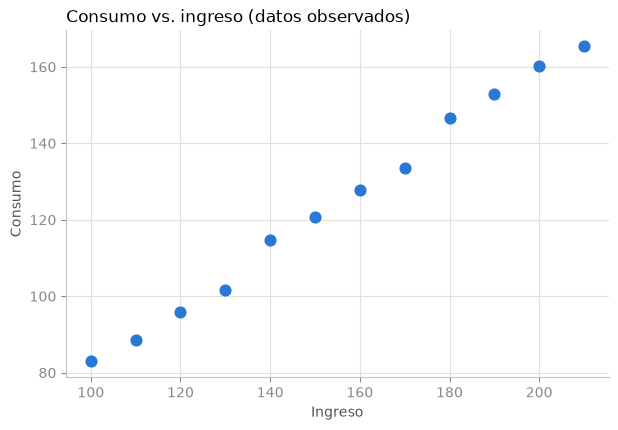

In [4]:
import matplotlib.pyplot as plt

# Estilo sobrio para todos los gráficos de la clase
plt.rcParams.update({
    'figure.figsize': (7, 4.5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.8,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': '#52514e',
    'xtick.color': '#898781',
    'ytick.color': '#898781',
})
AZUL, NARANJA = '#2a78d6', '#eb6834'

fig, ax = plt.subplots()
ax.scatter(datos['ingreso'], datos['consumo'], s=60, color=AZUL)
ax.set_xlabel('Ingreso')
ax.set_ylabel('Consumo')
ax.set_title('Consumo vs. ingreso (datos observados)', loc='left')
plt.show()

La relación es claramente **lineal y positiva**: a mayor ingreso, mayor
consumo. Pero el gráfico no lo dice todo — el precio también varía entre
observaciones. Para separar el efecto de cada variable necesitamos la
**regresión múltiple**.

## 3️⃣ Teoría: MCO en forma matricial

Apilamos las $n$ observaciones en matrices:

$$\underbrace{\begin{bmatrix} \text{consumo}_1 \\ \vdots \\ \text{consumo}_n \end{bmatrix}}_{y \;(n\times 1)} = \underbrace{\begin{bmatrix} 1 & \text{ingreso}_1 & \text{precio}_1 \\ \vdots & \vdots & \vdots \\ 1 & \text{ingreso}_n & \text{precio}_n \end{bmatrix}}_{X \;(n\times k)} \underbrace{\begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \end{bmatrix}}_{\beta \;(k\times 1)} + u$$

es decir, $y = X\beta + u$. La columna de unos en $X$ genera el **intercepto**
$\beta_0$.

El estimador MCO minimiza la suma de los residuos al cuadrado, y su fórmula es
la solución de las **ecuaciones normales**:

$$(X'X)\,\hat\beta = X'y \quad\Longrightarrow\quad \hat\beta = (X'X)^{-1}X'y$$

Todo lo que necesitamos son operaciones que ya conocemos: **transpuesta,
multiplicación de matrices e inversa** (o mejor aún: resolver el sistema).

## 4️⃣ Estimación con nuestra librería

`matriz_diseno()` construye $X$ y $y$ a partir del DataFrame: elige la columna
dependiente, agrega la columna de unos al inicio y devuelve también los
nombres de los coeficientes en orden.

In [5]:
X, y, nombres = matriz_diseno(datos, y='consumo', x=['ingreso', 'precio'])

print('X es de', X.shape, '→ (n observaciones × k coeficientes)')
print('y es de', y.shape, '→ vector columna')
print('Coeficientes a estimar:', nombres)
print()
print('Primeras filas de X:')
print(X[:4])

📐 Matriz de diseño: X (12, 3), y (12, 1)
   Coeficientes en orden: const, ingreso, precio
X es de (12, 3) → (n observaciones × k coeficientes)
y es de (12, 1) → vector columna
Coeficientes a estimar: ['const', 'ingreso', 'precio']

Primeras filas de X:
[[  1. 100.   5.]
 [  1. 110.   6.]
 [  1. 120.   7.]
 [  1. 130.   8.]]


Ahora estimamos $\hat\beta$ **paso a paso** con las ecuaciones normales:

In [6]:
XtX = X.T @ X     # matriz k×k
Xty = X.T @ y     # vector k×1

print("X'X =")
print(XtX)
print()
print("X'y =")
print(Xty)

# Resolver el sistema (X'X) beta = X'y
beta = np.linalg.solve(XtX, Xty)

print()
print('Coeficientes estimados:')
for nombre, valor in zip(nombres, beta.flatten()):
    print(f'   {nombre:>8}: {valor:8.3f}')

X'X =
[[    12.   1860.     78.]
 [  1860. 302600.  12240.]
 [    78.  12240.    522.]]

X'y =
[[  1491. ]
 [242299. ]
 [  9786.9]]

Coeficientes estimados:
      const:   10.910
    ingreso:    0.800
     precio:   -1.640


> 🧮 La fórmula del pizarrón es $\hat\beta = (X'X)^{-1}X'y$. Calculémosla
> **tal cual** con los comandos de NumPy — `np.linalg.inv()` para la inversa
> y `@` para multiplicar — y comparemos con `np.linalg.solve()`, que resuelve
> el sistema **sin calcular la inversa explícita** (más rápido y más preciso
> numéricamente). Debe salir exactamente lo mismo:

In [7]:
XtX_inv = np.linalg.inv(XtX)        # (X'X)^(-1) con NumPy
print("(X'X)^(-1) =")
print(np.array2string(XtX_inv, precision=5, suppress_small=False))

beta_formula = XtX_inv @ Xty        # β̂ = (X'X)^(-1) X'y — la fórmula tal cual

print()
print("β̂ con la fórmula (X'X)⁻¹X'y :", beta_formula.flatten())
print("β̂ con np.linalg.solve       :", beta.flatten())
print('¿Sale lo mismo?', np.allclose(beta, beta_formula))

(X'X)^(-1) =
[[ 3.53281e+00 -7.03125e-03 -3.63021e-01]
 [-7.03125e-03  7.81250e-05 -7.81250e-04]
 [-3.63021e-01 -7.81250e-04  7.44792e-02]]

β̂ con la fórmula (X'X)⁻¹X'y : [10.91  0.8  -1.64]
β̂ con np.linalg.solve       : [10.91  0.8  -1.64]
¿Sale lo mismo? True


**Interpretación económica:**

- `const` ≈ **consumo autónomo**: lo que se consumiría con ingreso cero.
- `ingreso` es la **propensión marginal a consumir**: por cada unidad
  adicional de ingreso, el consumo sube ≈ 0.8 unidades (precio constante).
- `precio` tiene signo **negativo**, como esperaba la teoría.

## 5️⃣ ¿Qué tan bien ajusta el modelo?

Con $\hat\beta$ calculamos los **valores ajustados** $\hat y = X\hat\beta$ y
los **residuos** $\hat u = y - \hat y$. El $R^2$ mide la fracción de la
variación del consumo que el modelo explica:

$$R^2 = 1 - \frac{\hat u'\hat u}{\sum_i (y_i - \bar y)^2}$$

In [8]:
y_ajustado = X @ beta          # valores ajustados
residuos = y - y_ajustado      # residuos

SRC = (residuos.T @ residuos).item()              # suma de residuos al cuadrado
STC = ((y - y.mean()).T @ (y - y.mean())).item()  # suma total de cuadrados
r2 = 1 - SRC / STC

print(f'R² = {r2:.4f} → el modelo explica el {r2:.2%} de la variación del consumo')

R² = 0.9998 → el modelo explica el 99.98% de la variación del consumo


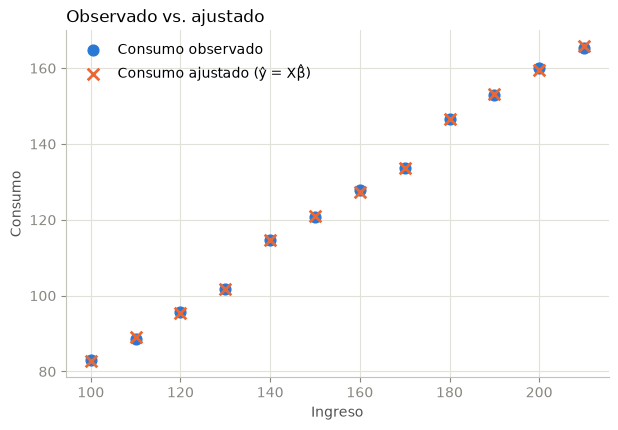

In [9]:
fig, ax = plt.subplots()
ax.scatter(datos['ingreso'], y.flatten(), s=60, color=AZUL,
           label='Consumo observado')
ax.scatter(datos['ingreso'], y_ajustado.flatten(), s=70, color=NARANJA,
           marker='x', linewidths=2, label='Consumo ajustado (ŷ = Xβ̂)')
ax.set_xlabel('Ingreso')
ax.set_ylabel('Consumo')
ax.set_title('Observado vs. ajustado', loc='left')
ax.legend(frameon=False)
plt.show()

## 6️⃣ Réplica "desde cero" con pandas + NumPy

Nada de lo anterior es magia: `cargar_datos()` y `matriz_diseno()` solo nos
ahorraron pasos. Hagamos **exactamente lo mismo** usando pandas y NumPy
directamente — así se ve lo que la librería hace por dentro.

In [10]:
# 1. Leer el CSV con pandas
datos_pd = pd.read_csv('datos_consumo.csv')

# 2. Construir a mano la matriz de diseño: columna de unos + regresores
n = len(datos_pd)
X_pd = np.column_stack([
    np.ones(n),                              # columna de la constante
    datos_pd[['ingreso', 'precio']].to_numpy(),
])
y_pd = datos_pd['consumo'].to_numpy().reshape(-1, 1)   # vector columna n×1

# 3. Ecuaciones normales, igual que antes
beta_pd = np.linalg.solve(X_pd.T @ X_pd, X_pd.T @ y_pd)

print('β̂ con pandas + NumPy :', beta_pd.flatten())
print('β̂ con algebra_lineal :', beta.flatten())
print('¿Idénticos?', np.allclose(beta, beta_pd))

β̂ con pandas + NumPy : [10.91  0.8  -1.64]
β̂ con algebra_lineal : [10.91  0.8  -1.64]
¿Idénticos? True


NumPy también trae un estimador de mínimos cuadrados listo para usar,
`np.linalg.lstsq`, que resuelve el mismo problema con un método numérico más
robusto:

In [11]:
beta_lstsq, *_ = np.linalg.lstsq(X_pd, y_pd, rcond=None)
print('β̂ con np.linalg.lstsq:', beta_lstsq.flatten())

β̂ con np.linalg.lstsq: [10.91  0.8  -1.64]


## 7️⃣ Exportar los resultados a Excel

Como en clase, podemos mandar cualquier matriz a un Excel con `exportar()` —
el archivo se crea si no existe. Y con `guardar_datos()` guardamos una tabla
ordenada (DataFrame) en `.csv` o `.xlsx`:

In [12]:
# La matriz beta → pestaña 'beta' de un Excel nuevo
exportar('beta', sheet_name='mi_regresion.xlsx')

# Y una tabla ordenada con nombres → CSV
tabla = pd.DataFrame({'coeficiente': nombres,
                      'estimacion': beta.flatten().round(4)})
guardar_datos(tabla, 'resultados_consumo.csv')
tabla


✅ beta → creada
🎯 ¡Exportadas exitosamente!: beta
🔗 Revisa tu archivo — 📊 Excel local: mi_regresion.xlsx
✅ Guardado: resultados_consumo.csv (3 filas × 2 columnas)


,coeficiente,estimacion
0,const,10.91
1,ingreso,0.80
2,precio,-1.64


> 📊 Abre el Excel `mi_regresion.xlsx` que acabas de generar (pestaña `beta`)
> y compáralo con la tabla anterior: los coeficientes deben coincidir.

## 8️⃣ `statsmodels`: la salida profesional

En econometría aplicada no calcularás $\hat\beta$ a mano: usarás librerías
como **statsmodels**, que además de los coeficientes entregan los errores
estándar, los estadísticos $t$, los valores $p$ y los intervalos de confianza.
Por dentro, hace exactamente el álgebra matricial de este notebook.

En la salida, fíjate en que:

- la columna **`coef`** coincide con nuestro $\hat\beta$,
- **`R-squared`** coincide con nuestro $R^2$,
- el resto (**`std err`**, **`t`**, **`P>|t|`**, intervalos) mide la
  *precisión* de las estimaciones — lo estudiarás en el curso de econometría.

In [13]:
import statsmodels.api as sm
import warnings

modelo = sm.OLS(y_pd, X_pd)     # mismas matrices y, X de la sección 6
resultado = modelo.fit()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # muestra pequeña (n=12): silenciar avisos
    print(resultado.summary(xname=nombres))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.595e+04
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           1.19e-17
Time:                        21:05:22   Log-Likelihood:                -4.6537
No. Observations:                  12   AIC:                             15.31
Df Residuals:                       9   BIC:                             16.76
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.9100      0.774     14.096      0.0

## 9️⃣ La "verdad" detrás de los datos

Confesión: los datos de esta clase fueron **generados** con la fórmula

$$\text{consumo} = 10 + 0.8\,\text{ingreso} - 1.5\,\text{precio} + \text{ruido}$$

Compara con tu $\hat\beta$: MCO recuperó los parámetros verdaderos con notable
precisión. Con datos reales nunca conocemos la "verdad" — por eso en
econometría importan los supuestos del modelo y las medidas de precisión de
los estimadores.

## ✏️ Ejercicios

Debajo de cada enunciado está la **solución en una celda con el código
oculto**. Intenta resolver cada ejercicio primero en celdas nuevas; cuando
termines, despliega la solución (haz clic en los puntos suspensivos «⋯» de
la celda colapsada) y ejecútala para comparar.

**1. Variable omitida.** Estima el modelo solo con el ingreso:
`matriz_diseno(datos, y='consumo', x=['ingreso'])`. ¿Cambia la PMC estimada?
¿Por qué? ¿Y el $R^2$?

In [14]:
# 👀 Solución 1 — variable omitida (intenta primero por tu cuenta)
X1, y1, nombres1 = matriz_diseno(datos, y='consumo', x=['ingreso'])
beta1 = np.linalg.solve(X1.T @ X1, X1.T @ y1)

b, b1 = beta.flatten(), beta1.flatten()
print('Coeficiente    completo   solo ingreso')
print(f'const       {b[0]:10.3f}   {b1[0]:10.3f}')
print(f'ingreso     {b[1]:10.3f}   {b1[1]:10.3f}')
print(f'precio      {b[2]:10.3f}       (omitido)')

res1 = y1 - X1 @ beta1
r2_1 = 1 - (res1.T @ res1).item() / ((y1 - y1.mean()).T @ (y1 - y1.mean())).item()
print(f'\nR² solo con ingreso: {r2_1:.4f}   (completo: {r2:.4f})')

print('\nLa PMC cambia poco porque en esta muestra el ingreso y el precio están\n'
      'poco correlacionados: el sesgo por variable omitida es pequeño. El R²\n'
      'baja porque el precio sí explica parte del consumo.')

📐 Matriz de diseño: X (12, 2), y (12, 1)
   Coeficientes en orden: const, ingreso
Coeficiente    completo   solo ingreso
const           10.910        2.916
ingreso          0.800        0.783
precio          -1.640       (omitido)

R² solo con ingreso: 0.9957   (completo: 0.9998)

La PMC cambia poco porque en esta muestra el ingreso y el precio están
poco correlacionados: el sesgo por variable omitida es pequeño. El R²
baja porque el precio sí explica parte del consumo.


**2. Sin constante.** Repite la estimación con `constante=False`. ¿Qué pasa
con los coeficientes? ¿Tiene sentido económico un consumo autónomo igual a
cero?

In [15]:
# 👀 Solución 2 — sin constante (intenta primero por tu cuenta)
X2, y2, nombres2 = matriz_diseno(datos, y='consumo', x=['ingreso', 'precio'],
                                 constante=False)
beta2 = np.linalg.solve(X2.T @ X2, X2.T @ y2)

print('Sin constante:')
for nombre, valor in zip(nombres2, beta2.flatten()):
    print(f'   {nombre:>8}: {valor:8.3f}')

print('\nSin β₀ obligamos al plano de regresión a pasar por el origen: los\n'
      'coeficientes se distorsionan para compensar el consumo autónomo que\n'
      'eliminamos. Como el consumo autónomo existe (β₀ ≈ 10.9), quitarlo no\n'
      'tiene sentido económico en este modelo.')

📐 Matriz de diseño: X (12, 2), y (12, 1)
   Coeficientes en orden: ingreso, precio
Sin constante:
    ingreso:    0.822
     precio:   -0.519

Sin β₀ obligamos al plano de regresión a pasar por el origen: los
coeficientes se distorsionan para compensar el consumo autónomo que
eliminamos. Como el consumo autónomo existe (β₀ ≈ 10.9), quitarlo no
tiene sentido económico en este modelo.


**3. Predicción.** Con tu $\hat\beta$: ¿cuánto consumo predice el modelo para
`ingreso = 220` y `precio = 6`? *(Pista: arma el vector fila
$x_0 = [1, 220, 6]$ y calcula $x_0\hat\beta$.)*

In [16]:
# 👀 Solución 3 — predicción (intenta primero por tu cuenta)
x0 = np.array([[1, 220, 6]])          # vector fila 1×k
consumo_pred = (x0 @ beta).item()     # x₀ β̂
print(f'Consumo predicho (ingreso=220, precio=6): {consumo_pred:.2f}')

Consumo predicho (ingreso=220, precio=6): 177.07


**4. Mini-proyecto: la ecuación de salarios.** El archivo
[`datos_salarios.csv`](https://raw.githubusercontent.com/franperezec/propedeutico-flacso/main/clases/matrices/datos_salarios.csv)
contiene datos **simulados** de 60 personas: `salario` (USD al mes),
`educacion` (años de estudio) y `experiencia` (años de trabajo). Es una
versión simplificada de la famosa **ecuación de Mincer**. Trabaja las cinco
partes; cada una tiene su solución oculta más abajo:

a) **Estadísticos descriptivos.** Calcula el resumen (`describe()`) y la
   matriz de correlaciones (`corr()`). ¿Qué variable se correlaciona más con
   el salario? ¿Te sorprende la correlación con la experiencia?

b) **Gráfico descriptivo.** Haz el gráfico más adecuado para estos datos.
   *(Pista: la variable dependiente contra cada regresor.)* ¿Qué forma tiene
   cada relación?

c) **Estimación y réplica.** Estima
   $\text{salario}_i = \beta_0 + \beta_1\,\text{educacion}_i + \beta_2\,\text{experiencia}_i + u_i$
   con la librería + NumPy (ecuaciones normales), replica "desde cero" con
   pandas + NumPy y verifica con `statsmodels`. Los tres $\hat\beta$ deben
   coincidir.

d) **Interpretación.** ¿Cuánto "paga" un año más de educación? ¿Y un año más
   de experiencia? ¿Lo que viste en (b) te hace dudar de alguna de estas
   lecturas?

e) **¿Experiencia al cuadrado?** La teoría del capital humano dice que el
   perfil salario-experiencia es **cóncavo**: sube al inicio, se aplana y
   puede caer. Agrega el regresor $\text{experiencia}^2$, reestima y evalúa:
   ¿mejora el $R^2$? ¿Es significativo el término nuevo en `statsmodels`?
   ¿A cuántos años de experiencia está el máximo del perfil?
   *(Pista: el máximo de $\beta_2\,e + \beta_3\,e^2$ está en
   $e^* = -\beta_2 / (2\beta_3)$.)*

La celda siguiente descarga (si hace falta) y carga la base — ese es tu punto
de partida:

In [17]:
# Punto de partida del ejercicio 4: descargar (si hace falta) y cargar la base
import os
if not os.path.exists('datos_salarios.csv'):
    from urllib.request import urlretrieve
    urlretrieve('https://raw.githubusercontent.com/franperezec/'
                'propedeutico-flacso/main/clases/matrices/datos_salarios.csv',
                'datos_salarios.csv')
    print('📥 datos_salarios.csv descargado')

salarios = cargar_datos('datos_salarios.csv')
salarios.head()

✅ datos_salarios.csv → 60 filas × 3 columnas: salario, educacion, experiencia


,salario,educacion,experiencia
0,2634.5,18.0,29.0
1,1507.3,8.0,6.0
2,1546.7,6.0,28.0
3,2368.4,15.0,27.0
4,1927.3,11.0,29.0


In [18]:
# 👀 Solución 4a — estadísticos descriptivos (intenta primero por tu cuenta)
print(salarios.describe().round(1))
print('\nMatriz de correlaciones:')
print(salarios.corr().round(2))

print('\nLa educación tiene la correlación más alta con el salario (≈ 0.81).\n'
      'La de la experiencia (≈ 0.47) parece decir que importa poco... pero\n'
      'cuidado: la correlación solo mide relaciones LINEALES. Si el perfil\n'
      'sube y luego baja, la correlación lineal lo subestima. El gráfico de\n'
      '(b) lo revela.')

       salario  educacion  experiencia
count     60.0       60.0         60.0
mean    2100.1       12.7         15.4
std      481.4        4.0          8.5
min      857.3        6.0          0.0
25%     1835.0       10.0          9.8
50%     2126.8       12.0         15.0
75%     2486.9       15.2         22.2
max     3074.7       20.0         30.0

Matriz de correlaciones:
             salario  educacion  experiencia
salario         1.00       0.81         0.47
educacion       0.81       1.00         0.07
experiencia     0.47       0.07         1.00

La educación tiene la correlación más alta con el salario (≈ 0.81).
La de la experiencia (≈ 0.47) parece decir que importa poco... pero
cuidado: la correlación solo mide relaciones LINEALES. Si el perfil
sube y luego baja, la correlación lineal lo subestima. El gráfico de
(b) lo revela.


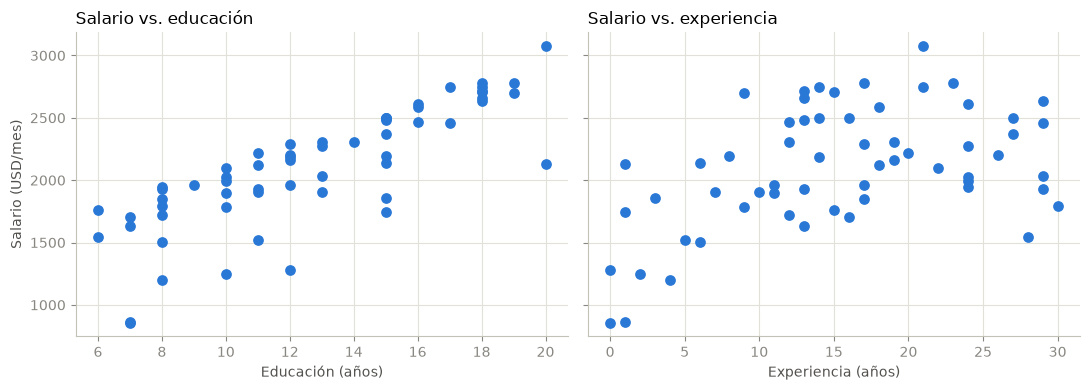

Educación: relación lineal y positiva, muy nítida.
Experiencia: nube más dispersa (la educación varía entre personas) y
con forma de ARCO: sube al inicio y se aplana o cae hacia el final.
Eso es justo lo que motiva el término cuadrático de la parte (e).


In [19]:
# 👀 Solución 4b — el gráfico más adecuado: dispersión de y contra cada regresor
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].scatter(salarios['educacion'], salarios['salario'], s=45, color=AZUL)
axes[0].set_xlabel('Educación (años)')
axes[0].set_ylabel('Salario (USD/mes)')
axes[0].set_title('Salario vs. educación', loc='left')

axes[1].scatter(salarios['experiencia'], salarios['salario'], s=45, color=AZUL)
axes[1].set_xlabel('Experiencia (años)')
axes[1].set_title('Salario vs. experiencia', loc='left')

plt.tight_layout()
plt.show()

print('Educación: relación lineal y positiva, muy nítida.\n'
      'Experiencia: nube más dispersa (la educación varía entre personas) y\n'
      'con forma de ARCO: sube al inicio y se aplana o cae hacia el final.\n'
      'Eso es justo lo que motiva el término cuadrático de la parte (e).')

In [20]:
# 👀 Solución 4c — estimar y replicar: librería, pandas + NumPy, statsmodels
# (1) Con la librería + NumPy: matriz de diseño y ecuaciones normales
Xs, ys, nombres_s = matriz_diseno(salarios, y='salario',
                                  x=['educacion', 'experiencia'])
beta_s = np.linalg.solve(Xs.T @ Xs, Xs.T @ ys)

# (2) "Desde cero" con pandas + NumPy
sal_pd = pd.read_csv('datos_salarios.csv')
Xs_pd = np.column_stack([np.ones(len(sal_pd)),
                         sal_pd[['educacion', 'experiencia']].to_numpy()])
ys_pd = sal_pd['salario'].to_numpy().reshape(-1, 1)
beta_s_pd = np.linalg.solve(Xs_pd.T @ Xs_pd, Xs_pd.T @ ys_pd)

# (3) Con statsmodels
modelo_s = sm.OLS(ys_pd, Xs_pd).fit()

print('β̂ librería + NumPy :', beta_s.flatten().round(3))
print('β̂ pandas + NumPy   :', beta_s_pd.flatten().round(3))
print('β̂ statsmodels      :', modelo_s.params.round(3))
print('¿Coinciden los tres?', np.allclose(beta_s, beta_s_pd) and
      np.allclose(beta_s.flatten(), modelo_s.params))
print(f'\nR² del modelo lineal: {modelo_s.rsquared:.4f}')

📐 Matriz de diseño: X (60, 3), y (60, 1)
   Coeficientes en orden: const, educacion, experiencia
β̂ librería + NumPy : [525.695  95.507  23.623]
β̂ pandas + NumPy   : [525.695  95.507  23.623]
β̂ statsmodels      : [525.695  95.507  23.623]
¿Coinciden los tres? True

R² del modelo lineal: 0.8354


In [21]:
# 👀 Solución 4d — interpretación de los β̂ del modelo lineal
b0_s, b1_s, b2_s = beta_s.flatten()
print(f'const       ≈ {b0_s:7.1f} → salario "base" (educación y experiencia en 0)')
print(f'educacion   ≈ {b1_s:7.1f} → un año más de estudio paga ≈ {b1_s:.0f} USD/mes más')
print(f'experiencia ≈ {b2_s:7.1f} → un año más de experiencia paga ≈ {b2_s:.0f} USD/mes más')

print('\nLa lectura de la educación es creíble: el gráfico (b) mostró una\n'
      'relación lineal. La de la experiencia NO: el perfil tiene forma de\n'
      'arco, y este modelo le impone una recta. Su β es solo un efecto\n'
      'PROMEDIO que mezcla años que suman mucho (al inicio de la carrera)\n'
      'con años que suman poco o restan (al final). Lo corregimos en (e).')

const       ≈   525.7 → salario "base" (educación y experiencia en 0)
educacion   ≈    95.5 → un año más de estudio paga ≈ 96 USD/mes más
experiencia ≈    23.6 → un año más de experiencia paga ≈ 24 USD/mes más

La lectura de la educación es creíble: el gráfico (b) mostró una
relación lineal. La de la experiencia NO: el perfil tiene forma de
arco, y este modelo le impone una recta. Su β es solo un efecto
PROMEDIO que mezcla años que suman mucho (al inicio de la carrera)
con años que suman poco o restan (al final). Lo corregimos en (e).


In [22]:
# 👀 Solución 4e — ¿experiencia al cuadrado?
# Agregamos e² como columna nueva (en una copia, para no alterar 'salarios')
salarios_q = salarios.assign(exper2=salarios['experiencia'] ** 2)

Xq, yq, nombres_q = matriz_diseno(salarios_q, y='salario',
                                  x=['educacion', 'experiencia', 'exper2'])
beta_q = np.linalg.solve(Xq.T @ Xq, Xq.T @ yq)

res_q = yq - Xq @ beta_q
r2_q = 1 - (res_q.T @ res_q).item() / ((yq - yq.mean()).T @ (yq - yq.mean())).item()

print('Coeficientes con experiencia²:')
for nombre, valor in zip(nombres_q, beta_q.flatten()):
    print(f'   {nombre:>12}: {valor:9.3f}')
print(f'\nR²: {modelo_s.rsquared:.4f} (lineal)  →  {r2_q:.4f} (con experiencia²)')

# Significancia del término cuadrático con statsmodels
modelo_q = sm.OLS(yq, Xq).fit()
print()
print(modelo_q.summary(xname=nombres_q))

bq = beta_q.flatten()
pico = -bq[2] / (2 * bq[3])
print(f'\nEl coeficiente de experiencia² es NEGATIVO y muy significativo\n'
      f'(P>|t| ≈ 0): el perfil es cóncavo, como dice la teoría. El salario\n'
      f'sube con la experiencia hasta e* = -β₂/(2β₃) = {pico:.1f} años y de ahí\n'
      f'en adelante cae. (La base se generó con β = (200, 90, 100, -2.5),\n'
      f'así que el pico verdadero está en 100/(2·2.5) = 20 años.)')

print('\nNota: el modelo sigue siendo LINEAL EN LOS PARÁMETROS — experiencia²\n'
      'es solo una columna más de X, y MCO lo estima sin ningún cambio. (El\n'
      'aviso de "condition number" del summary es normal al incluir e y e²,\n'
      'que están muy correlacionadas entre sí.)')

📐 Matriz de diseño: X (60, 4), y (60, 1)
   Coeficientes en orden: const, educacion, experiencia, exper2
Coeficientes con experiencia²:
          const:   190.691
      educacion:    91.608
    experiencia:    97.791
         exper2:    -2.455

R²: 0.8354 (lineal)  →  0.9837 (con experiencia²)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     1125.
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           5.48e-50
Time:                        21:05:23   Log-Likelihood:                -331.78
No. Observations:                  60   AIC:                             671.6
Df Residuals:                      56   BIC:                             679.9
Df Model:                           3                                   